In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Mobile = pd.read_excel("mobile_sales.xlsx")
Mobile

,Brand,Product Code,Price,Inward Date,Dispatch Date,Quantity,Customer Name,Customer Location,Region,Processor Specification,RAM,ROM
0,Motorola,88EB4558,78570,2023-08-02,2023-08-03,6,William Hess,South Kelsey,Central,Snapdragon 7 Gen,12GB,128GB
1,Samsung,9F975B08,159826,2025-03-19,2025-03-20,5,Leah Copeland,South Todd,Central,MediaTek Dimensity,8GB,256GB
2,Dell,14932CAE,11670,2023-10-10,2023-10-16,6,Nicole Gonzalez,South Miguel,North,Apple A-Series,16GB,256GB
3,Motorola,E3CF42BE,174698,2025-02-09,2025-03-20,10,Miranda Clayton,North Deanna,North,MediaTek Dimensity,6GB,64GB
4,Apple,F54013D6,51251,2023-04-03,2023-04-19,9,Ms. Katie Anderson,Lake Laurenfort,North,Snapdragon 8 Gen,4GB,256GB
...,...,...,...,...,...,...,...,...,...,...,...,...
24978,iQOO,31862428,149619,2025-02-04,2025-04-01,5,Jamie Wood,Madisonmouth,South,Snapdragon 8 Gen,32GB,512GB
24979,Asus,6E2ACD6E,20144,2023-04-11,2023-04-29,3,Michael Brown,New Robertside,South,MediaTek Dimensity,8GB,64GB
24980,Nokia,07D68A35,143290,2025-02-25,2025-04-12,8,Mrs. Kayla Nguyen MD,Nicolestad,South,Snapdragon 7s,4GB,64GB
24981,Motorola,65CE4E22,159525,2023-06-16,2023-08-10,8,Alice Sims,Danieltown,Central,Apple A-Series,4GB,64GB


In [3]:
Mobile.shape

(24983, 12)

In [4]:
Mobile.size

299796

In [5]:
Mobile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24983 entries, 0 to 24982
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Brand                    24983 non-null  object        
 1   Product Code             24983 non-null  object        
 2   Price                    24983 non-null  int64         
 3   Inward Date              24983 non-null  datetime64[ns]
 4   Dispatch Date            24983 non-null  datetime64[ns]
 5   Quantity                 24983 non-null  int64         
 6   Customer Name            24983 non-null  object        
 7   Customer Location        24983 non-null  object        
 8   Region                   24983 non-null  object        
 9   Processor Specification  24983 non-null  object        
 10  RAM                      24983 non-null  object        
 11  ROM                      24983 non-null  object        
dtypes: datetime64[ns](2), int64(2), 

In [6]:
Mobile.describe()

,Price,Inward Date,Dispatch Date,Quantity
count,24983.000000,24983,24983,24983.000000
mean,102498.006364,2024-03-20 05:31:18.605452032,2024-04-19 19:34:30.832165888,5.510547
min,5008.000000,2023-03-21 00:00:00,2023-03-23 00:00:00,1.000000
25%,53151.500000,2023-09-21 00:00:00,2023-10-22 00:00:00,3.000000
50%,102751.000000,2024-03-19 00:00:00,2024-04-18 00:00:00,5.000000
75%,151319.500000,2024-09-18 12:00:00,2024-10-19 00:00:00,8.000000
max,199999.000000,2025-03-20 00:00:00,2025-05-18 00:00:00,10.000000
std,56478.485813,NaN,NaN,2.879988


In [7]:
Mobile.columns

Index(['Brand', 'Product Code', 'Price', 'Inward Date', 'Dispatch Date',
       'Quantity', 'Customer Name', 'Customer Location', 'Region',
       'Processor Specification', 'RAM', 'ROM'],
      dtype='object')

## Pandas

In [35]:
top10brands = Mobile.groupby("Brand")["Price"].max().reset_index()
top10brands = top10brands.sort_values(by="Price", ascending=False).head(10).reset_index(drop=True)

print(top10brands)


      Brand   Price
0      Asus  199999
1      Dell  199997
2      iQOO  199991
3   OnePlus  199991
4     Nokia  199988
5   Toshiba  199983
6      Vivo  199947
7    Realme  199947
8     Apple  199940
9  Motorola  199908


In [9]:
custo = Mobile.groupby("Customer Name")["Quantity"].sum()
top10cust = custo.sort_values(ascending=False).head(10).reset_index()

print(top10cust)


           Customer Name  Quantity
0       Michael Williams        73
1        Robert Williams        69
2  Christopher Hernandez        61
3            James Smith        57
4            James Davis        56
5          Michael Jones        55
6      Michael Rodriguez        52
7            James Brown        51
8      Christopher Davis        47
9           David Miller        46


In [10]:
processor = Mobile.groupby("Processor Specification")["Product Code"].count()
processor = processor.sort_values(ascending=False).reset_index()
processor.columns = ["Processor Specification", "Product Count"]

print(processor)

  Processor Specification  Product Count
0      MediaTek Dimensity           3640
1        Snapdragon 8 Gen           3614
2           Snapdragon 7s           3590
3          Samsung Exynos           3581
4          Apple A-Series           3565
5        Snapdragon 7 Gen           3563
6          MediaTek Helio           3430


In [11]:
regionprice = Mobile.groupby("Region")["Price"].agg(["min","max"]).reset_index()
regionprice.columns = ["Region","Min Price","Max Price"]

print(regionprice)

    Region  Min Price  Max Price
0  Central       5008     199997
1     East       5125     199964
2    North       5098     199948
3    South       5057     199983
4     West       5011     199999


In [12]:
location = Mobile.groupby("Customer Location")["Quantity"].sum().reset_index()
locations = location.sort_values(by="Quantity", ascending=False).head(100).reset_index(drop=True)

print(locations)

   Customer Location  Quantity
0      South Michael       162
1       East Michael       135
2         West James       133
3          East John       119
4       Port Michael       112
..               ...       ...
95      Jessicamouth        56
96    South Patricia        55
97      Lake Rebecca        55
98      South Thomas        55
99         Lake Lisa        55

[100 rows x 2 columns]


In [13]:
Mobile["RAM GB"] = Mobile["RAM"].str.replace("GB","").astype(int)
Mobile["ROM GB"] = Mobile["ROM"].str.replace("GB|TB","", regex=True).astype(int) * \
                   Mobile["ROM"].str.contains("TB").map({True:1024, False:1})

highspec = Mobile[(Mobile["RAM GB"] >= 12) & (Mobile["ROM GB"] >= 256)]

columns = ["Brand","Processor Specification","RAM GB","ROM GB"]
highspec = highspec[columns]

highspec = highspec.drop_duplicates(subset=["Brand","Processor Specification","RAM GB","ROM GB"]).reset_index(drop=True)
print(highspec)


         Brand Processor Specification  RAM GB  ROM GB
0         Dell          Apple A-Series      16     256
1       Realme        Snapdragon 7 Gen      16     512
2      Samsung          MediaTek Helio      16     256
3         Acer          MediaTek Helio      12     256
4         iQOO        Snapdragon 7 Gen      16     512
...        ...                     ...     ...     ...
1251  Motorola          Apple A-Series      16     512
1252      iQOO        Snapdragon 7 Gen      16    1024
1253    Huawei        Snapdragon 8 Gen      12    1024
1254      Acer          MediaTek Helio      12    1024
1255      Acer        Snapdragon 7 Gen      12     512

[1256 rows x 4 columns]


In [14]:
Mobile["Delivery days"] = (Mobile["Dispatch Date"] - Mobile["Inward Date"]).dt.days
avg = Mobile.groupby("Region",as_index=False)["Delivery days"].mean().round(2)

print(avg)


    Region  Delivery days
0  Central          30.36
1     East          30.66
2    North          30.48
3    South          30.84
4     West          30.58


In [15]:
Mobile["Revenue"] = Mobile["Price"] * Mobile["Quantity"]
revenue = Mobile.groupby("Region")["Revenue"].sum().reset_index()
revenue = revenue.sort_values(by="Revenue", ascending=False).reset_index(drop=True)

print(revenue)


    Region     Revenue
0     West  2874899918
1  Central  2855566556
2    South  2793277392
3     East  2784871125
4    North  2783051309


In [16]:
totalrevenuebrand = Mobile.groupby("Brand")["Revenue"].sum()
top5brandsrevenue = totalrevenuebrand.sort_values(ascending=False).head(5)

print(top5brandsrevenue)

Brand
Google       754735374
Huawei       730904622
Microsoft    729609709
Nokia        727513265
Toshiba      724188926
Name: Revenue, dtype: int64


## Matplotlib

In [17]:
Mobile.columns

Index(['Brand', 'Product Code', 'Price', 'Inward Date', 'Dispatch Date',
       'Quantity', 'Customer Name', 'Customer Location', 'Region',
       'Processor Specification', 'RAM', 'ROM', 'RAM GB', 'ROM GB',
       'Delivery days', 'Revenue'],
      dtype='object')

In [18]:
Mobile

,Brand,Product Code,Price,Inward Date,Dispatch Date,Quantity,Customer Name,Customer Location,Region,Processor Specification,RAM,ROM,RAM GB,ROM GB,Delivery days,Revenue
0,Motorola,88EB4558,78570,2023-08-02,2023-08-03,6,William Hess,South Kelsey,Central,Snapdragon 7 Gen,12GB,128GB,12,128,1,471420
1,Samsung,9F975B08,159826,2025-03-19,2025-03-20,5,Leah Copeland,South Todd,Central,MediaTek Dimensity,8GB,256GB,8,256,1,799130
2,Dell,14932CAE,11670,2023-10-10,2023-10-16,6,Nicole Gonzalez,South Miguel,North,Apple A-Series,16GB,256GB,16,256,6,70020
3,Motorola,E3CF42BE,174698,2025-02-09,2025-03-20,10,Miranda Clayton,North Deanna,North,MediaTek Dimensity,6GB,64GB,6,64,39,1746980
4,Apple,F54013D6,51251,2023-04-03,2023-04-19,9,Ms. Katie Anderson,Lake Laurenfort,North,Snapdragon 8 Gen,4GB,256GB,4,256,16,461259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24978,iQOO,31862428,149619,2025-02-04,2025-04-01,5,Jamie Wood,Madisonmouth,South,Snapdragon 8 Gen,32GB,512GB,32,512,56,748095
24979,Asus,6E2ACD6E,20144,2023-04-11,2023-04-29,3,Michael Brown,New Robertside,South,MediaTek Dimensity,8GB,64GB,8,64,18,60432
24980,Nokia,07D68A35,143290,2025-02-25,2025-04-12,8,Mrs. Kayla Nguyen MD,Nicolestad,South,Snapdragon 7s,4GB,64GB,4,64,46,1146320
24981,Motorola,65CE4E22,159525,2023-06-16,2023-08-10,8,Alice Sims,Danieltown,Central,Apple A-Series,4GB,64GB,4,64,55,1276200


In [19]:
Mobile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24983 entries, 0 to 24982
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Brand                    24983 non-null  object        
 1   Product Code             24983 non-null  object        
 2   Price                    24983 non-null  int64         
 3   Inward Date              24983 non-null  datetime64[ns]
 4   Dispatch Date            24983 non-null  datetime64[ns]
 5   Quantity                 24983 non-null  int64         
 6   Customer Name            24983 non-null  object        
 7   Customer Location        24983 non-null  object        
 8   Region                   24983 non-null  object        
 9   Processor Specification  24983 non-null  object        
 10  RAM                      24983 non-null  object        
 11  ROM                      24983 non-null  object        
 12  RAM GB                   24983 n

In [20]:
Mobile.isnull().sum()

Brand                      0
Product Code               0
Price                      0
Inward Date                0
Dispatch Date              0
Quantity                   0
Customer Name              0
Customer Location          0
Region                     0
Processor Specification    0
RAM                        0
ROM                        0
RAM GB                     0
ROM GB                     0
Delivery days              0
Revenue                    0
dtype: int64

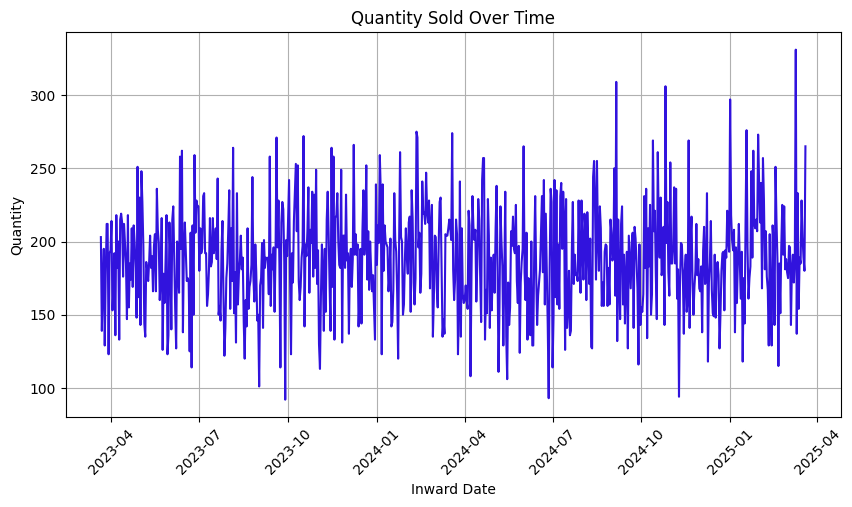

In [21]:
Mobile["Inward Date"] = pd.to_datetime(Mobile["Inward Date"])
dailysales = Mobile.groupby("Inward Date")["Quantity"].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(dailysales["Inward Date"], dailysales["Quantity"],color="#3113DD")
plt.title("Quantity Sold Over Time")
plt.xlabel("Inward Date")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

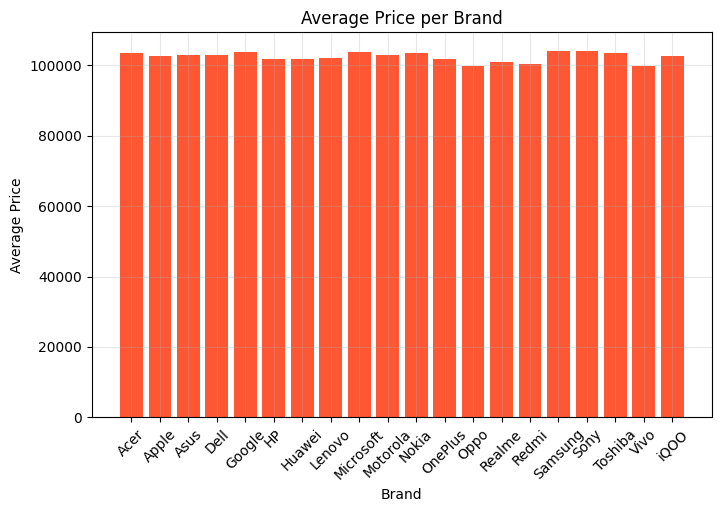

In [22]:
avgPrice = Mobile.groupby("Brand")["Price"].mean().reset_index()
plt.figure(figsize=(8,5))
plt.bar(avgPrice["Brand"],avgPrice["Price"], color="#FF5733")
plt.title("Average Price per Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()


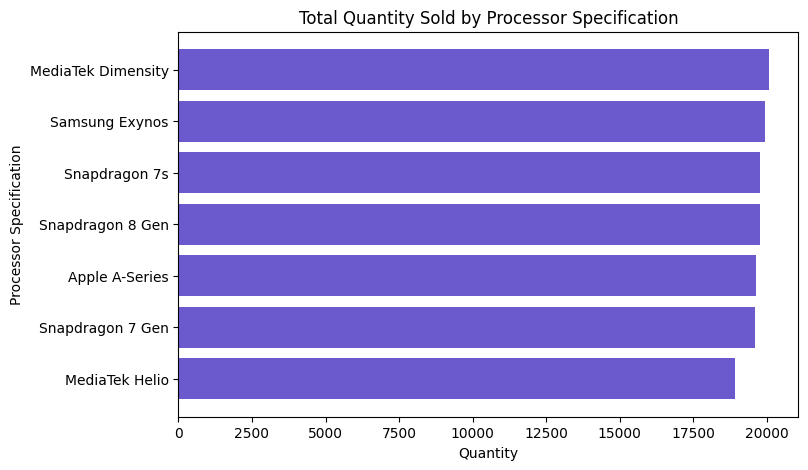

In [23]:
processorqty = Mobile.groupby("Processor Specification")["Quantity"].sum().sort_values()
plt.figure(figsize=(8,5))
plt.barh(processorqty.index, processorqty.values, color="#6A5ACD")
plt.title("Total Quantity Sold by Processor Specification")
plt.xlabel("Quantity")
plt.ylabel("Processor Specification")
plt.show()

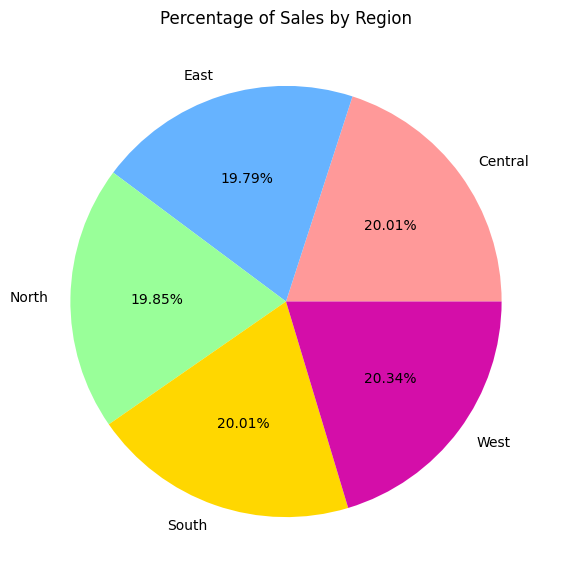

In [24]:
regionsales = Mobile.groupby("Region")["Quantity"].sum()
plt.figure(figsize=(7,7))
plt.pie(regionsales, labels=regionsales.index, autopct="%1.2f%%", colors=["#FF9999","#66B3FF","#99FF99","#FFD700","#D40EA9"])
plt.title("Percentage of Sales by Region")
plt.show()

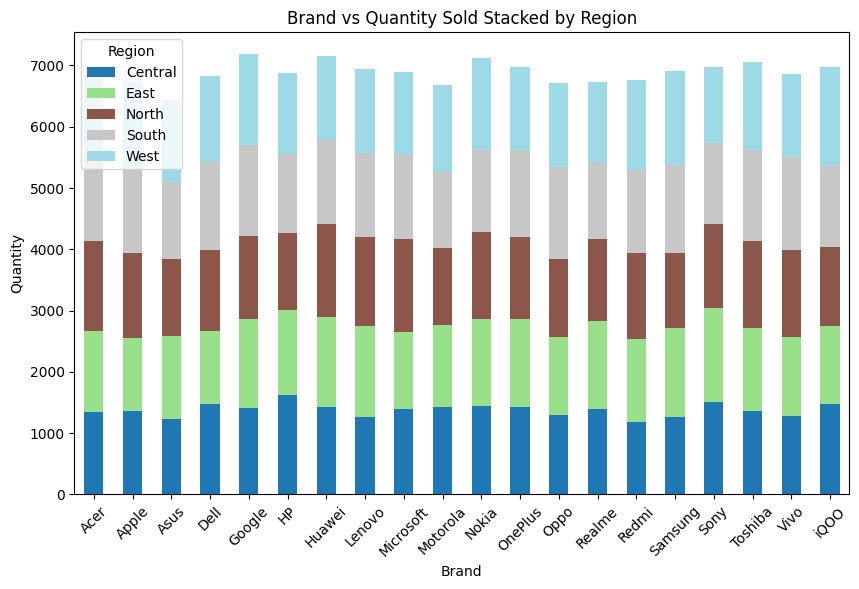

In [25]:
regionqty = Mobile.groupby(["Brand", "Region"])["Quantity"].sum().unstack()
regionqty.plot(kind="bar", stacked=True, figsize=(10,6), colormap="tab20")
plt.title("Brand vs Quantity Sold Stacked by Region")
plt.xlabel("Brand")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.legend(title="Region")
plt.show()

## Seaborn

In [37]:
Mobile.describe()

,Price,Inward Date,Dispatch Date,Quantity,RAM GB,ROM GB,Delivery days,Revenue
count,24983.000000,24983,24983,24983.000000,24983.000000,24983.000000,24983.000000,2.498300e+04
mean,102498.006364,2024-03-20 05:31:18.605452032,2024-04-19 19:34:30.832165888,5.510547,12.978746,396.447504,30.585558,5.640502e+05
min,5008.000000,2023-03-21 00:00:00,2023-03-23 00:00:00,1.000000,4.000000,64.000000,1.000000,5.181000e+03
25%,53151.500000,2023-09-21 00:00:00,2023-10-22 00:00:00,3.000000,6.000000,128.000000,16.000000,1.824945e+05
50%,102751.000000,2024-03-19 00:00:00,2024-04-18 00:00:00,5.000000,8.000000,256.000000,31.000000,4.372300e+05
75%,151319.500000,2024-09-18 12:00:00,2024-10-19 00:00:00,8.000000,16.000000,512.000000,45.000000,8.422315e+05
max,199999.000000,2025-03-20 00:00:00,2025-05-18 00:00:00,10.000000,32.000000,1024.000000,60.000000,1.998260e+06
std,56478.485813,NaN,NaN,2.879988,9.361447,348.917051,17.260333,4.579897e+05


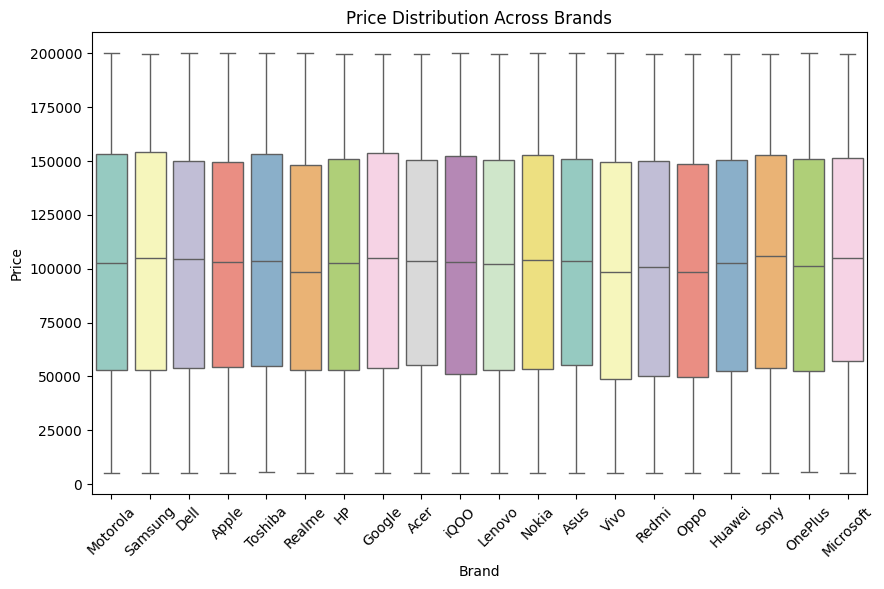

In [26]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Brand", y="Price", data=Mobile, hue="Brand", palette="Set3", dodge=False)
plt.title("Price Distribution Across Brands")
plt.xlabel("Brand")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

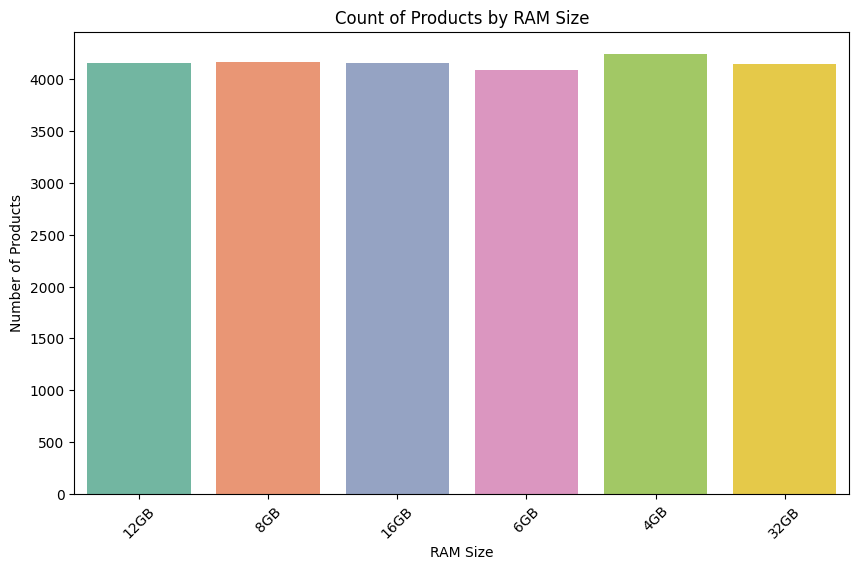

In [27]:
plt.figure(figsize=(10,6))
sns.countplot(x="RAM", data=Mobile, hue="RAM", palette="Set2", dodge=False)
plt.title("Count of Products by RAM Size")
plt.xlabel("RAM Size")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

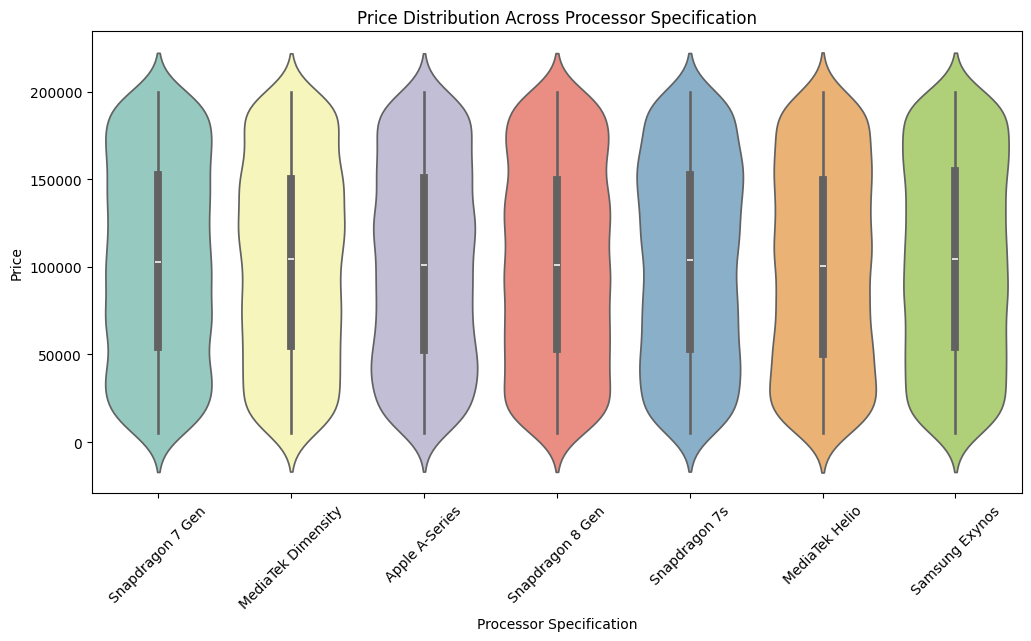

In [28]:
plt.figure(figsize=(12,6))
sns.violinplot(x="Processor Specification", y="Price", data=Mobile, hue="Processor Specification", palette="Set3", dodge=False)
plt.title("Price Distribution Across Processor Specification")
plt.xlabel("Processor Specification")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

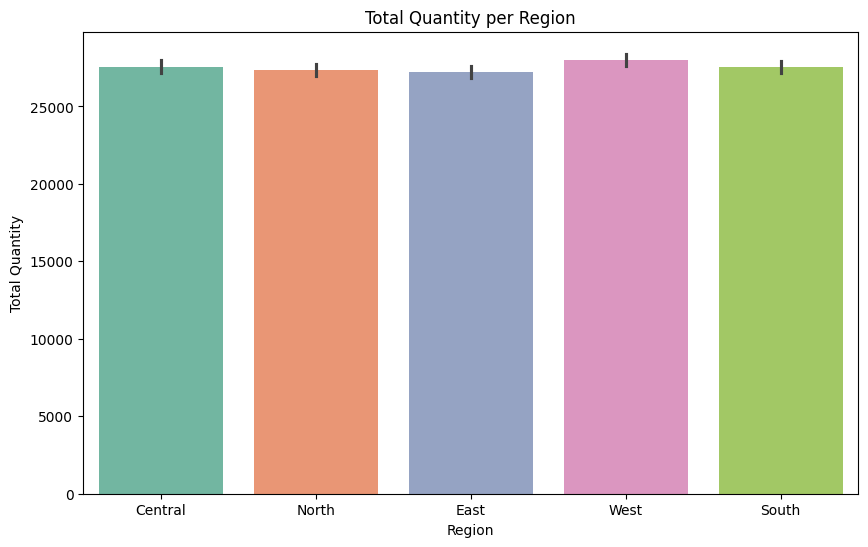

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(x="Region", y="Quantity", data=Mobile, hue="Region", estimator=sum, palette="Set2", dodge=False)
plt.title("Total Quantity per Region")
plt.xlabel("Region")
plt.ylabel("Total Quantity")
plt.show()

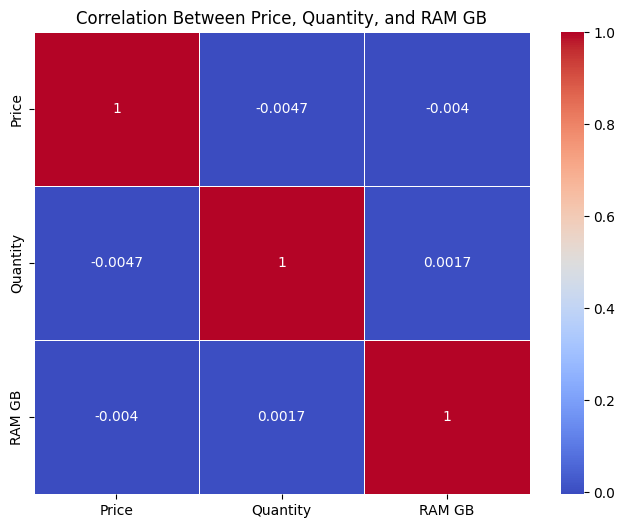

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(Mobile[["Price", "Quantity", "RAM GB"]].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between Price, Quantity, and RAM GB")
plt.show()

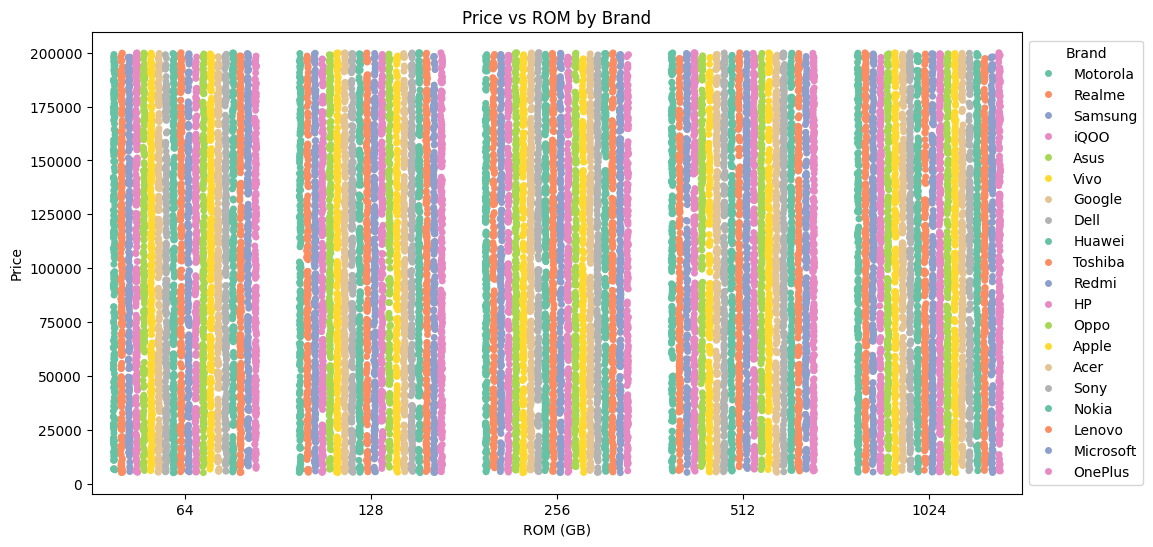

In [ ]:
plt.figure(figsize=(12,6))
sns.stripplot(x="ROM GB", y="Price", data=Mobile, hue="Brand", palette="Set2", jitter=True, dodge=True)
plt.title("Price vs ROM by Brand")
plt.xlabel("ROM (GB)")
plt.ylabel("Price")
plt.legend(title="Brand", loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()